# NS Railway Robustness Analysis

![Network Map](docs/map_raw.png)

**Goal:** find the weakest points in the Dutch railway (NS) network and propose new connections that make it more robust to disruptions.

**Approach:**
1. Build the network as a graph (stations = nodes, routes = edges)
2. Find critical stations using degree and betweenness centrality
3. Simulate removing each critical station and measure the impact on travel distance
4. Propose new connections between stations that are geographically close but far apart by train
5. Re-test the network with the new connections and compare before/after

### 1. Analysis methodology
1. Define reliability metrics and measurable target changes
2. Analyze current network
3. Identify potential weak edges/vertices
    * high betweenness edges
    * stations that are geographically close but not directly connected
4. Propose new routes
5. Re-test the network, comparing performance metrices of original and modified network. If there is an improvement, is it significant enough?

Brief Dictionary

* **Reliability** - The ability of the railway network to consistently perform its required functions under stated conditions for a specified period of time.
* **Robustness** - The capacity of the railway network to maintain its overall structure and function despite failures or adverse conditions.

### Content
1. Methodology
2. Results
    - 2.1 Basic network analysis
    - 2.2 Critical stations detection
    - 2.3 Proposing new stations
3. Results


#### 2.0 Preparation

In [73]:
!pip install graphviz
!pip install numpy
!pip install pandas
!pip install geopy
!pip install matplotlib
!pip install networkx
!pip install random
!pip install matplotlib


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement random (from versions: none)

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for random



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [74]:
import graphviz as pvg
import networkx as nx
from networkx.algorithms import community
import matplotlib.pyplot as plt
import pandas as pd
# from google.colab import drive
import random as rnd
import numpy as np
import geopy.distance

### Load the data

In [75]:
# # mount Google Drive
# enable_gdrive = True   # Switch to indicate whether Google Drive should be mounted.

# if enable_gdrive:
#     drive.mount('/content/gdrive')

In [76]:
# data_dir = r"/content/gdrive/MyDrive/Project Algorithms/data/"
data_dir = r"data/"

In [77]:
# Load dataframe
df_routes = pd.read_csv(data_dir + "routes.csv", delimiter=",")

In [78]:
df_routes.head()

,fromStation,toStation,distance
0,utm,bhv,62
1,bhv,utm,62
2,bhv,uto,56
3,uto,bhv,56
4,uto,ut,34


In [79]:
# Load dataframe
df_disruptions = pd.read_csv(data_dir + "disruptions-2023.csv", delimiter=",")

In [80]:
df_disruptions.head()

,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
0,45999,Amsterdam-Rotterdam-Brussel (HSL),"Amsterdam Centraal - Schiphol Airport, Rotterd...","24,32","Amsterdam Centraal,Amsterdam Lelylaan,Amsterda...","ASD, ASDL, ASS, RTD, SHL",wisselstoring,points failure,wisselstoring,points failure,infrastructure,2023-01-01 08:19:26,2023-01-01 22:43:08,864.0
1,46000,Zwolle-Leeuwarden,Leeuwarden - Zwolle,160,"Heerenveen,Wolvega,Heerenveen IJsstadion","HR, WV, HRY",dier op het spoor,an animal on the railway track,dier op het spoor,an animal on the railway track,external,2023-01-01 10:31:49,2023-01-01 10:56:17,24.0
2,46001,Heerlen-Aachen Hbf,Aachen Hbf - Heerlen,130,"Aachen Hbf,Eygelshoven Markt,Heerlen,Heerlen D...","AHBF, EGHM, HRL, HRLK, HZ, LG, AW",beperkingen in de materieelinzet,problems with the rolling stock,beperkingen in de materieelinzet,problems with the rolling stock,rolling stock,2023-01-01 13:19:24,2023-01-02 00:02:39,643.0
3,46002,Zutphen-Winterswijk,Winterswijk - Zutphen,83,"Vorden,Zutphen","VD, ZP",aanrijding,collision,aanrijding,collision,accidents,2023-01-01 17:15:22,2023-01-01 20:14:23,179.0
4,46003,Heerlen-Aachen Hbf,Aachen Hbf - Heerlen,130,"Aachen Hbf,Eygelshoven Markt,Heerlen,Heerlen D...","AHBF, EGHM, HRL, HRLK, HZ, LG, AW",beperkingen in de materieelinzet,problems with the rolling stock,beperkingen in de materieelinzet,problems with the rolling stock,rolling stock,2023-01-02 05:57:27,2023-01-03 02:07:13,1210.0


In [81]:
# Load dataframe
df_stations = pd.read_csv(data_dir + "stations-2023-09.csv", delimiter=",", keep_default_na=False)

In [82]:
df_stations.head()

,id,code,uic,name_short,name_medium,name_long,slug,country,type,geo_lat,geo_lng
0,266,HT,8400319,Den Bosch,'s-Hertogenbosch,'s-Hertogenbosch,s-hertogenbosch,NL,knooppuntIntercitystation,51.690480,5.293620
1,269,HTO,8400320,Dn Bosch O,'s-Hertogenb. O.,'s-Hertogenbosch Oost,s-hertogenbosch-oost,NL,stoptreinstation,51.700554,5.318333
2,227,HDE,8400388,'t Harde,'t Harde,'t Harde,t-harde,NL,stoptreinstation,52.409168,5.893611
3,8,AHBF,8015345,Aachen,Aachen Hbf,Aachen Hbf,aachen-hbf,D,knooppuntIntercitystation,50.767800,6.091499
4,818,AW,8015199,Aachen W,Aachen West,Aachen West,aachen-west,D,stoptreinstation,50.780360,6.070715


In [83]:
def _get_station_record_by_code(code):
  try:
    return df_stations.loc[df_stations["code"] == code.upper()]
  except IndexError:
    return None

def get_station_name_by_code(code):
  station = _get_station_record_by_code(code)
  return station["name_medium"].values[0]


def get_station_location_by_code(code):
  station = _get_station_record_by_code(code)
  return station["geo_lat"].values[0], station["geo_lng"].values[0]



# print(get_station_name_by_code('hd'))

print(get_station_location_by_code('hde'))

(np.float64(52.4091682), np.float64(5.893611))


In [84]:
def retrieve_station_record_by_code(code):
    station = df_stations.loc[df_stations["code"] == code.upper()]
    return station if not station.empty else None

def get_station_name_by_code(code):
    station = retrieve_station_record_by_code(code)
    return station["name_medium"].values[0] if station is not None else None

def get_station_location_by_code(code):
    station = retrieve_station_record_by_code(code)
    if station is not None:
        return station["geo_lat"].values[0], station["geo_lng"].values[0]
    else:
        return None, None

print(get_station_name_by_code("ht"))

print(get_station_location_by_code("ut"))


's-Hertogenbosch
(np.float64(52.088890075684), np.float64(5.1102776527405))


### Preprocess the data

In [85]:
df_routes.isnull().sum()

fromStation    0
toStation      0
distance       0
dtype: int64

In [86]:
df_disruptions.isnull().sum()

rdt_id                  0
ns_lines                0
rdt_lines               6
rdt_lines_id            6
rdt_station_names       6
rdt_station_codes       6
cause_nl                0
cause_en                0
statistical_cause_nl    0
statistical_cause_en    0
cause_group             0
start_time              0
end_time                8
duration_minutes        8
dtype: int64

In [87]:
df_stations.isnull().sum()

id             0
code           0
uic            0
name_short     0
name_medium    0
name_long      0
slug           0
country        0
type           0
geo_lat        0
geo_lng        0
dtype: int64

In [88]:
# Correcting the name inconsistency manually
df_stations['code'] = df_stations['code'].replace('DTCP', 'DTZ') # station Delft Zuid was renamed to Delft Campus

#### 2.1 Overview of railway network

In [89]:
# load network as a graph
G = nx.from_pandas_edgelist(df_routes, source="fromStation", target="toStation", edge_attr="distance")

C:\Users\Andrii\AppData\Local\Temp\ipykernel_34572\4117459451.py:7: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  fig = plt.figure(1, figsize=(200, 80), dpi=100)


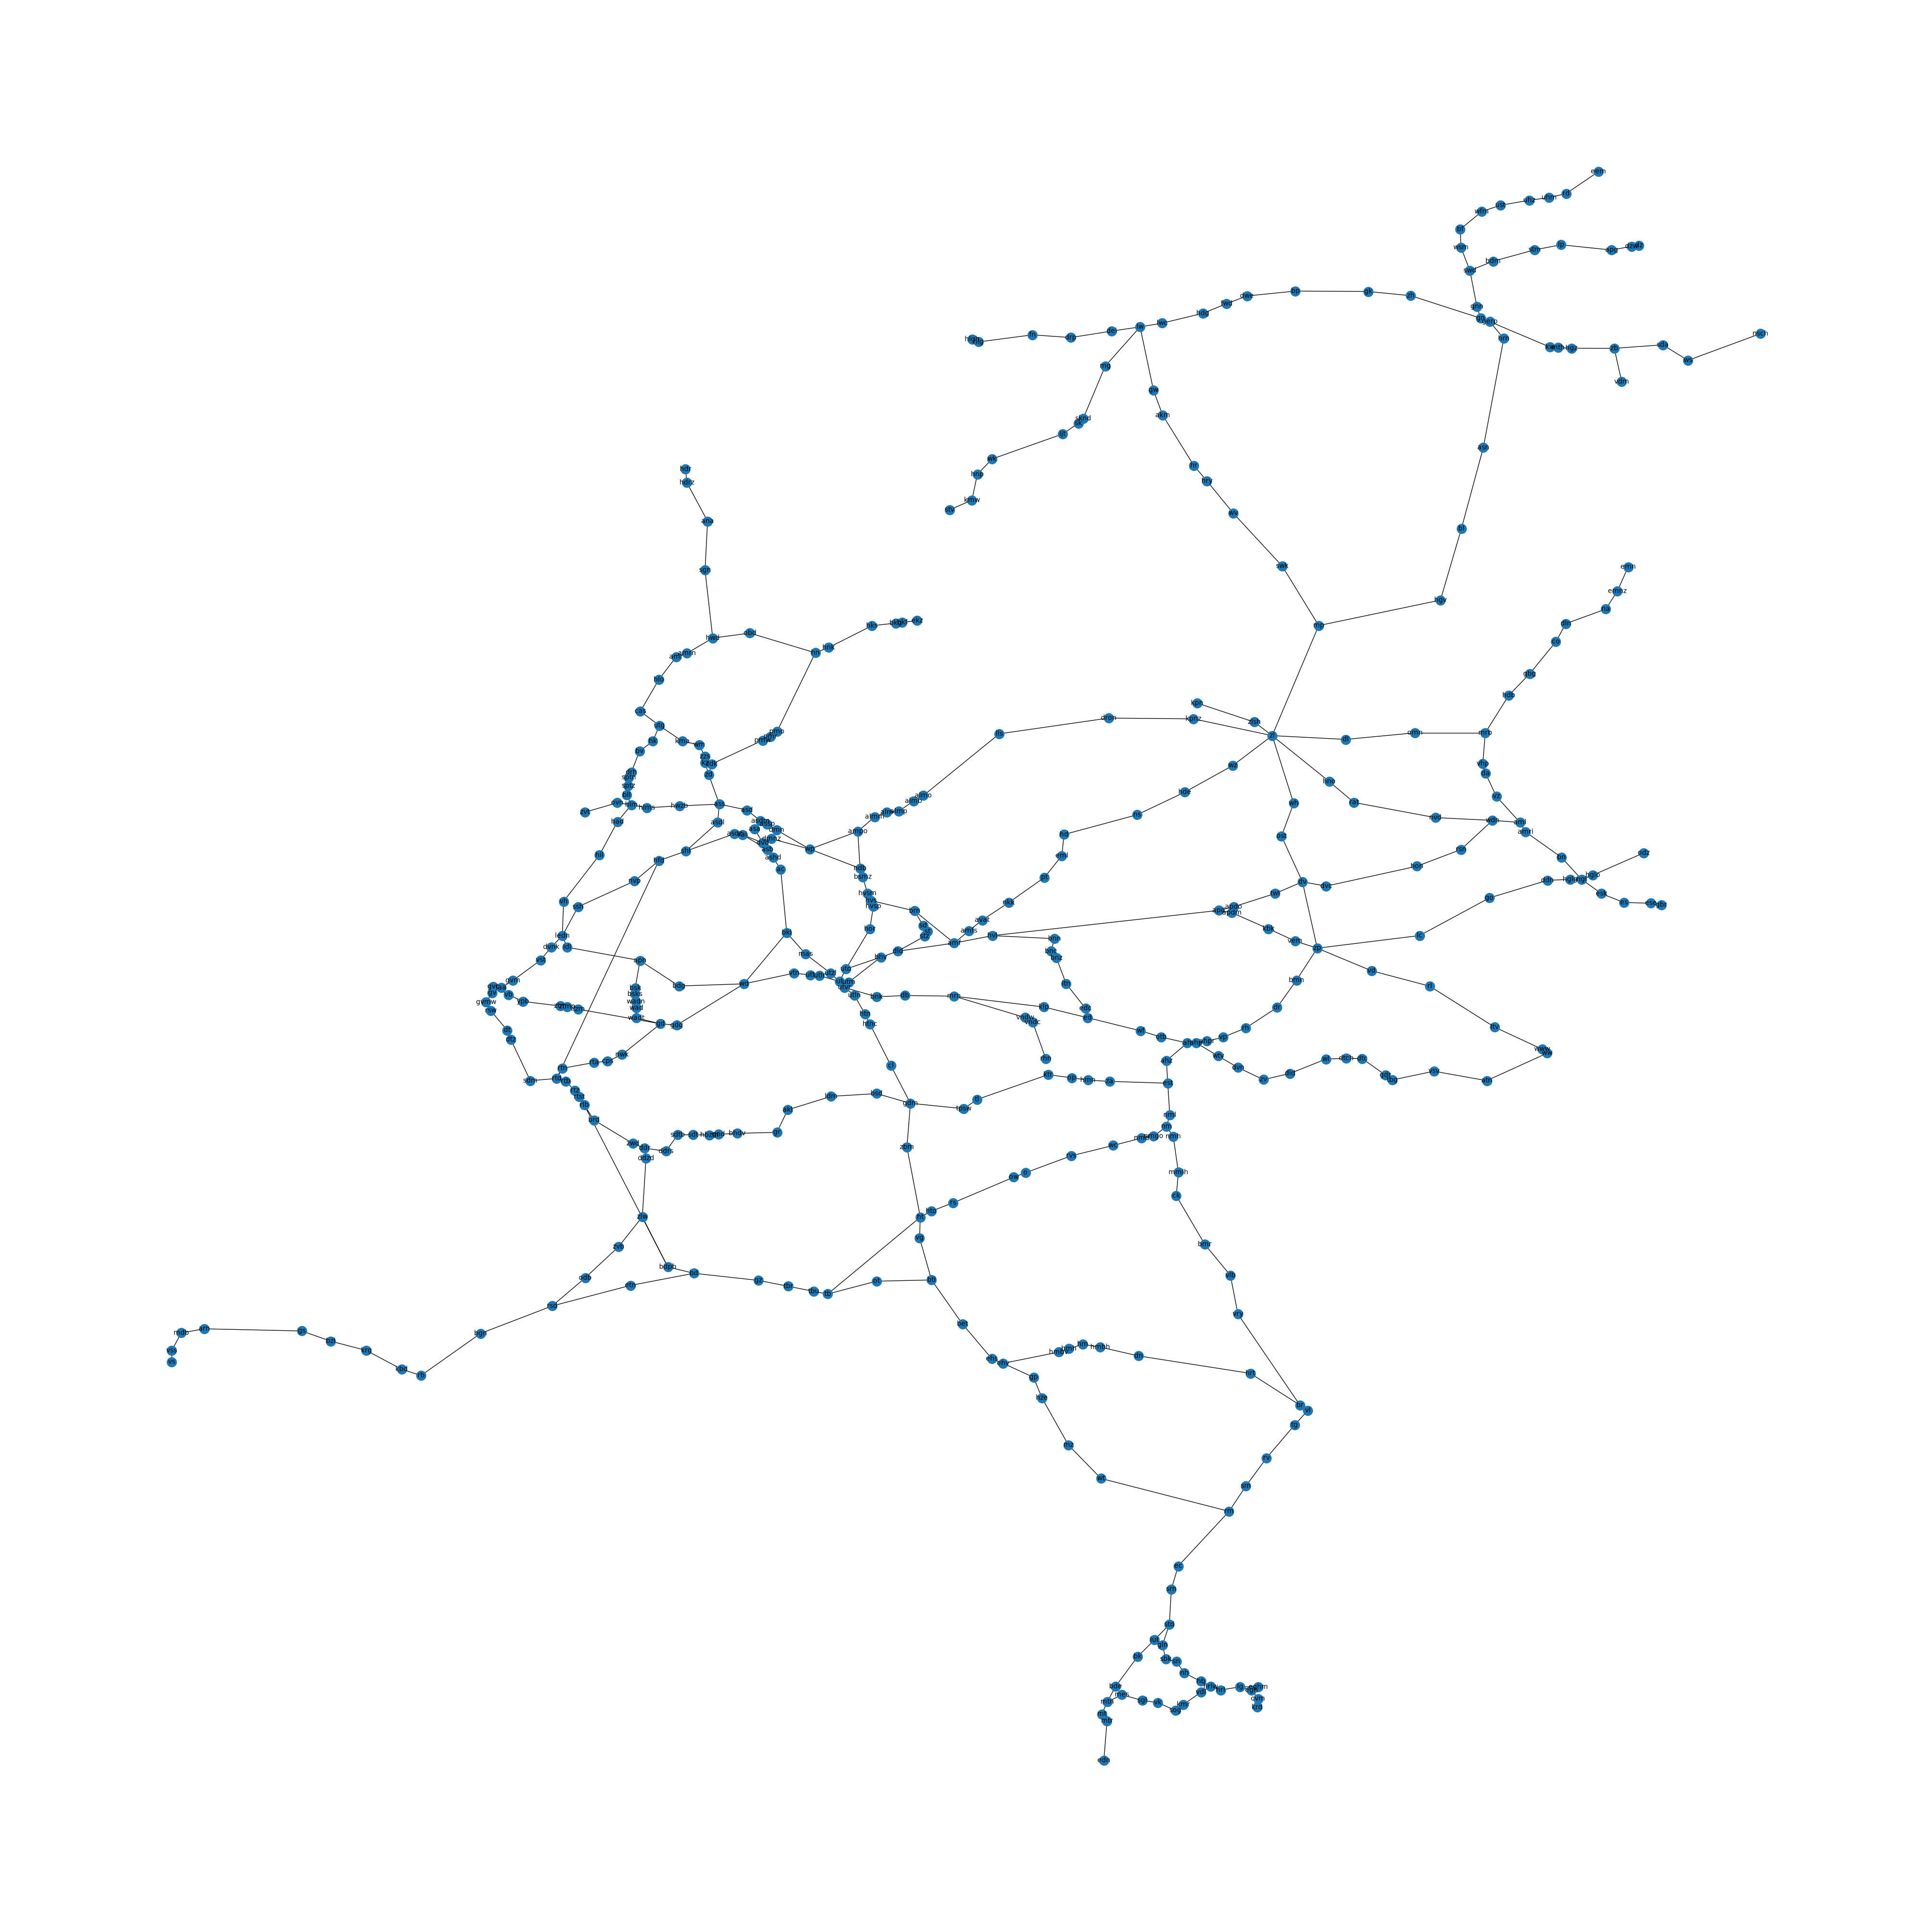

In [90]:
# Draw each node using its geolocation
node_positions = {str(row['code']).lower(): (row['geo_lng'], row['geo_lat']) for _, row in df_stations.iterrows()}

nx.draw(G, pos=node_positions, with_labels=True, font_size=10, node_size=200)

# Change canvas size
fig = plt.figure(1, figsize=(200, 80), dpi=100)
fig.set_size_inches(40, 40)
plt.show()

Above, you can see a graph representing the Dutch railway network. The stations are positioned according to their actual geographical coordinates (longitude and latitude), and each node is labeled with an abbreviation of its name. This allows us to visually inspect which parts of the network are the most vulnerable. We found this map quite useful for evaluating our intermediate results and verifying our assumptions.

For example, it is immediately apparent that station Zwolle (northeastern part, abbreviated as "zl") is critical. Removing it would completely disconnect a significant part of the network, namely the provinces of Friesland and Groningen, and potentially make the province of Drenthe much less accessible. This could have a substantial impact, as these areas are home to around 1.8 million inhabitants, which is close to 10% of the population of the Netherlands.


In [91]:
print(f"Graph has {nx.number_of_nodes(G)} nodes and {nx.number_of_edges(G)} edges")

Graph has 397 nodes and 433 edges


In [92]:
max_degree = 0;
max_node = None
for node in G.nodes():
  if G.degree(node) > max_degree:
    max_degree = G.degree(node)
    max_node = node
print(f"the node with the highest degree is {get_station_name_by_code(node)} with {max_degree} edges")


the node with the highest degree is Horst-Sevenum with 7 edges


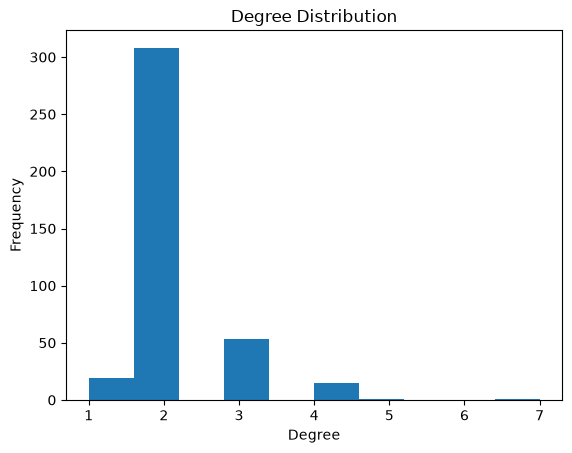

In [93]:
degree_sequence = [degree for node, degree in G.degree()]
plt.hist(degree_sequence)
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.title('Degree Distribution')
plt.show()

Most stations in our railway network have a degree of 2, indicating that they primarily serve as connections between two other stations rather than being significant destinations or hubs themselves.

They serve as critical links between routes, but they may also represent potential single points of failure. If one of these stations experiences disruptions (e.g., due to maintenance, accidents, or signal failures), it could significantly impact the entire route connected to it.

Our response to such problem is promoting a limited amount of additional interconnections between routes that lie close next to each other. Thus, in case of disruptions on one route, an alternative path should be possible.

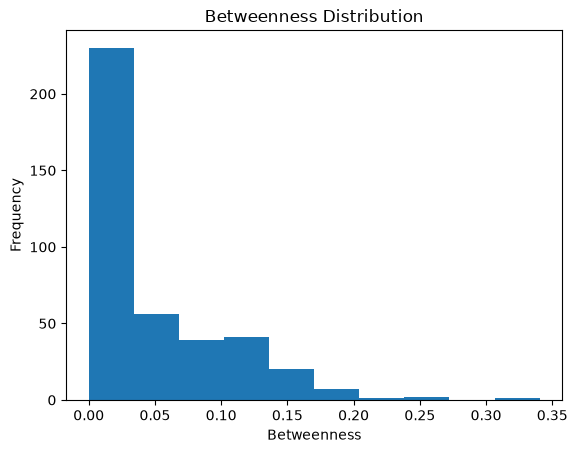

In [94]:
betweenness_sequence = [centrality for node, centrality in nx.betweenness_centrality(G).items()]
plt.hist(betweenness_sequence)
plt.xlabel('Betweenness')
plt.ylabel('Frequency')
plt.title('Betweenness Distribution')
plt.show()

Stations with high betweenness centrality serve as crucial transfer hubs, where multiple routes converge, and a large number of passengers interchange trains. Disruptions at these hubs can have cascading effects on the entire network, impacting connectivity and travel times.

Stations with high betweenness require robust emergency response plans to manage disruptions effectively. Rapid intervention and alternative routing strategies are essential to minimize the impact of incidents at these critical points.

Analyzing the distribution of high-betweenness stations can inform network optimization efforts. Identifying opportunities to reduce congestion, improve transfer facilities, and optimize routing can enhance the efficiency and reliability of the entire network.

High-betweenness stations are key focal points for resilience planning. Developing redundancy measures, backup infrastructure, and alternative routing options can mitigate the impact of disruptions and ensure continuity of service.

Identify weak points based on these measures:
*   degree (how many stations are directly connected to this station?)
*   betweenness (how many shortest routes go through this station?)

Areas around stations with high betweenness are our main candidates to adjustments. Why? If this station or its adjacent edges face a disruption, this means multiple routes have to be rescheduled. Within the scope of our studies, we consider that the only alternative way is through a different station, which makes the travel distance longer. It is worth noting that in real life, it is not necessary the case, because a different platform might be used instead.  

We also might want to promote some redundancy in the places where there are long chains of stations with degree of 2, because otherwise failure of one of them will consequently lead to failure of all the following ones in the chain, or at least a  longer alternative path. To solve this, we think it would make sense to create additional connections of such chains to a close path, so there is always an adequate alternative path.


In [95]:
# Community Detection
communities = community.greedy_modularity_communities(G)
print(communities)

# Centrality Measures
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G, distance='distance')

# Print top 5 stations by centrality measures
top_stations_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
top_stations_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
top_stations_closeness = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 stations by degree centrality:", top_stations_degree)
print("Top 5 stations by betweenness centrality:", top_stations_betweenness)
print("Top 5 stations by closeness centrality:", top_stations_closeness)

# Select critical stations, which have top n% betweenness
betweenness_values = np.array(list(betweenness_centrality.values()))
betweenness_min_crit_value = np.percentile(betweenness_values, 95) # top 5%

critical_stations = [node for node, centrality in betweenness_centrality.items() if centrality > betweenness_min_crit_value]

print(f"Selected critical stations with high betweenness: {critical_stations}")

[frozenset({'hm', 'rv', 'btl', 'gp', 'bet', 'vg', 'tbu', 'sm', 'rs', 'nmh', 'ehv', 'hmbh', 'rvs', 'hmh', 'rm', 'dn', 'srn', 'mmlh', 'tb', 'ow', 'ec', 'wt', 'ot', 'ck', 'ehs', 'vl', 'hrt', 'mz', 'hmbv', 'nmgo', 'bmr', 'br', 'vry', 'wc', 'nm', 'o', 'hze', 'ht', 'nmd', 'tg', 'vlb', 'hto'}), frozenset({'lwc', 'asn', 'hlgh', 'gnn', 'lw', 'hry', 'zh', 'akm', 'gn', 'mth', 'fwd', 'gk', 'ws', 'hgz', 'gw', 'hrn', 'hlg', 'sda', 'wv', 'fn', 'swk', 'bp', 'hr', 'gerp', 'vdm', 'zb', 'kw', 'nsch', 'hdg', 'hgv', 'dei', 'bl', 'mp', 'drp', 'dwe'}), frozenset({'mrn', 'akl', 'bhdv', 'wf', 'ktr', 'est', 'hmn', 'utvr', 'gnd', 'tl', 'utln', 'ahz', 'htn', 'za', 'htnc', 'gr', 'edc', 'otb', 'zbm', 'vndc', 'rhn', 'ed', 'tpsw', 'ldm', 'bsd', 'db', 'klp', 'op', 'ah', 'gdm', 'cl', 'nml', 'bnk', 'vndw'}), frozenset({'wm', 'pmr', 'hn', 'hnk', 'zdk', 'ekz', 'hks', 'bkg', 'zd', 'bv', 'drh', 'bkf', 'zzs', 'bll', 'amr', 'cas', 'hk', 'kma', 'hwd', 'hdrz', 'amrn', 'obd', 'utg', 'pmo', 'sgn', 'sptz', 'kz', 'ana', 'hlo', 'pmw

C:\Users\Andrii\AppData\Local\Temp\ipykernel_34572\3485493284.py:17: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  fig = plt.figure(1, figsize=(200, 80), dpi=60)


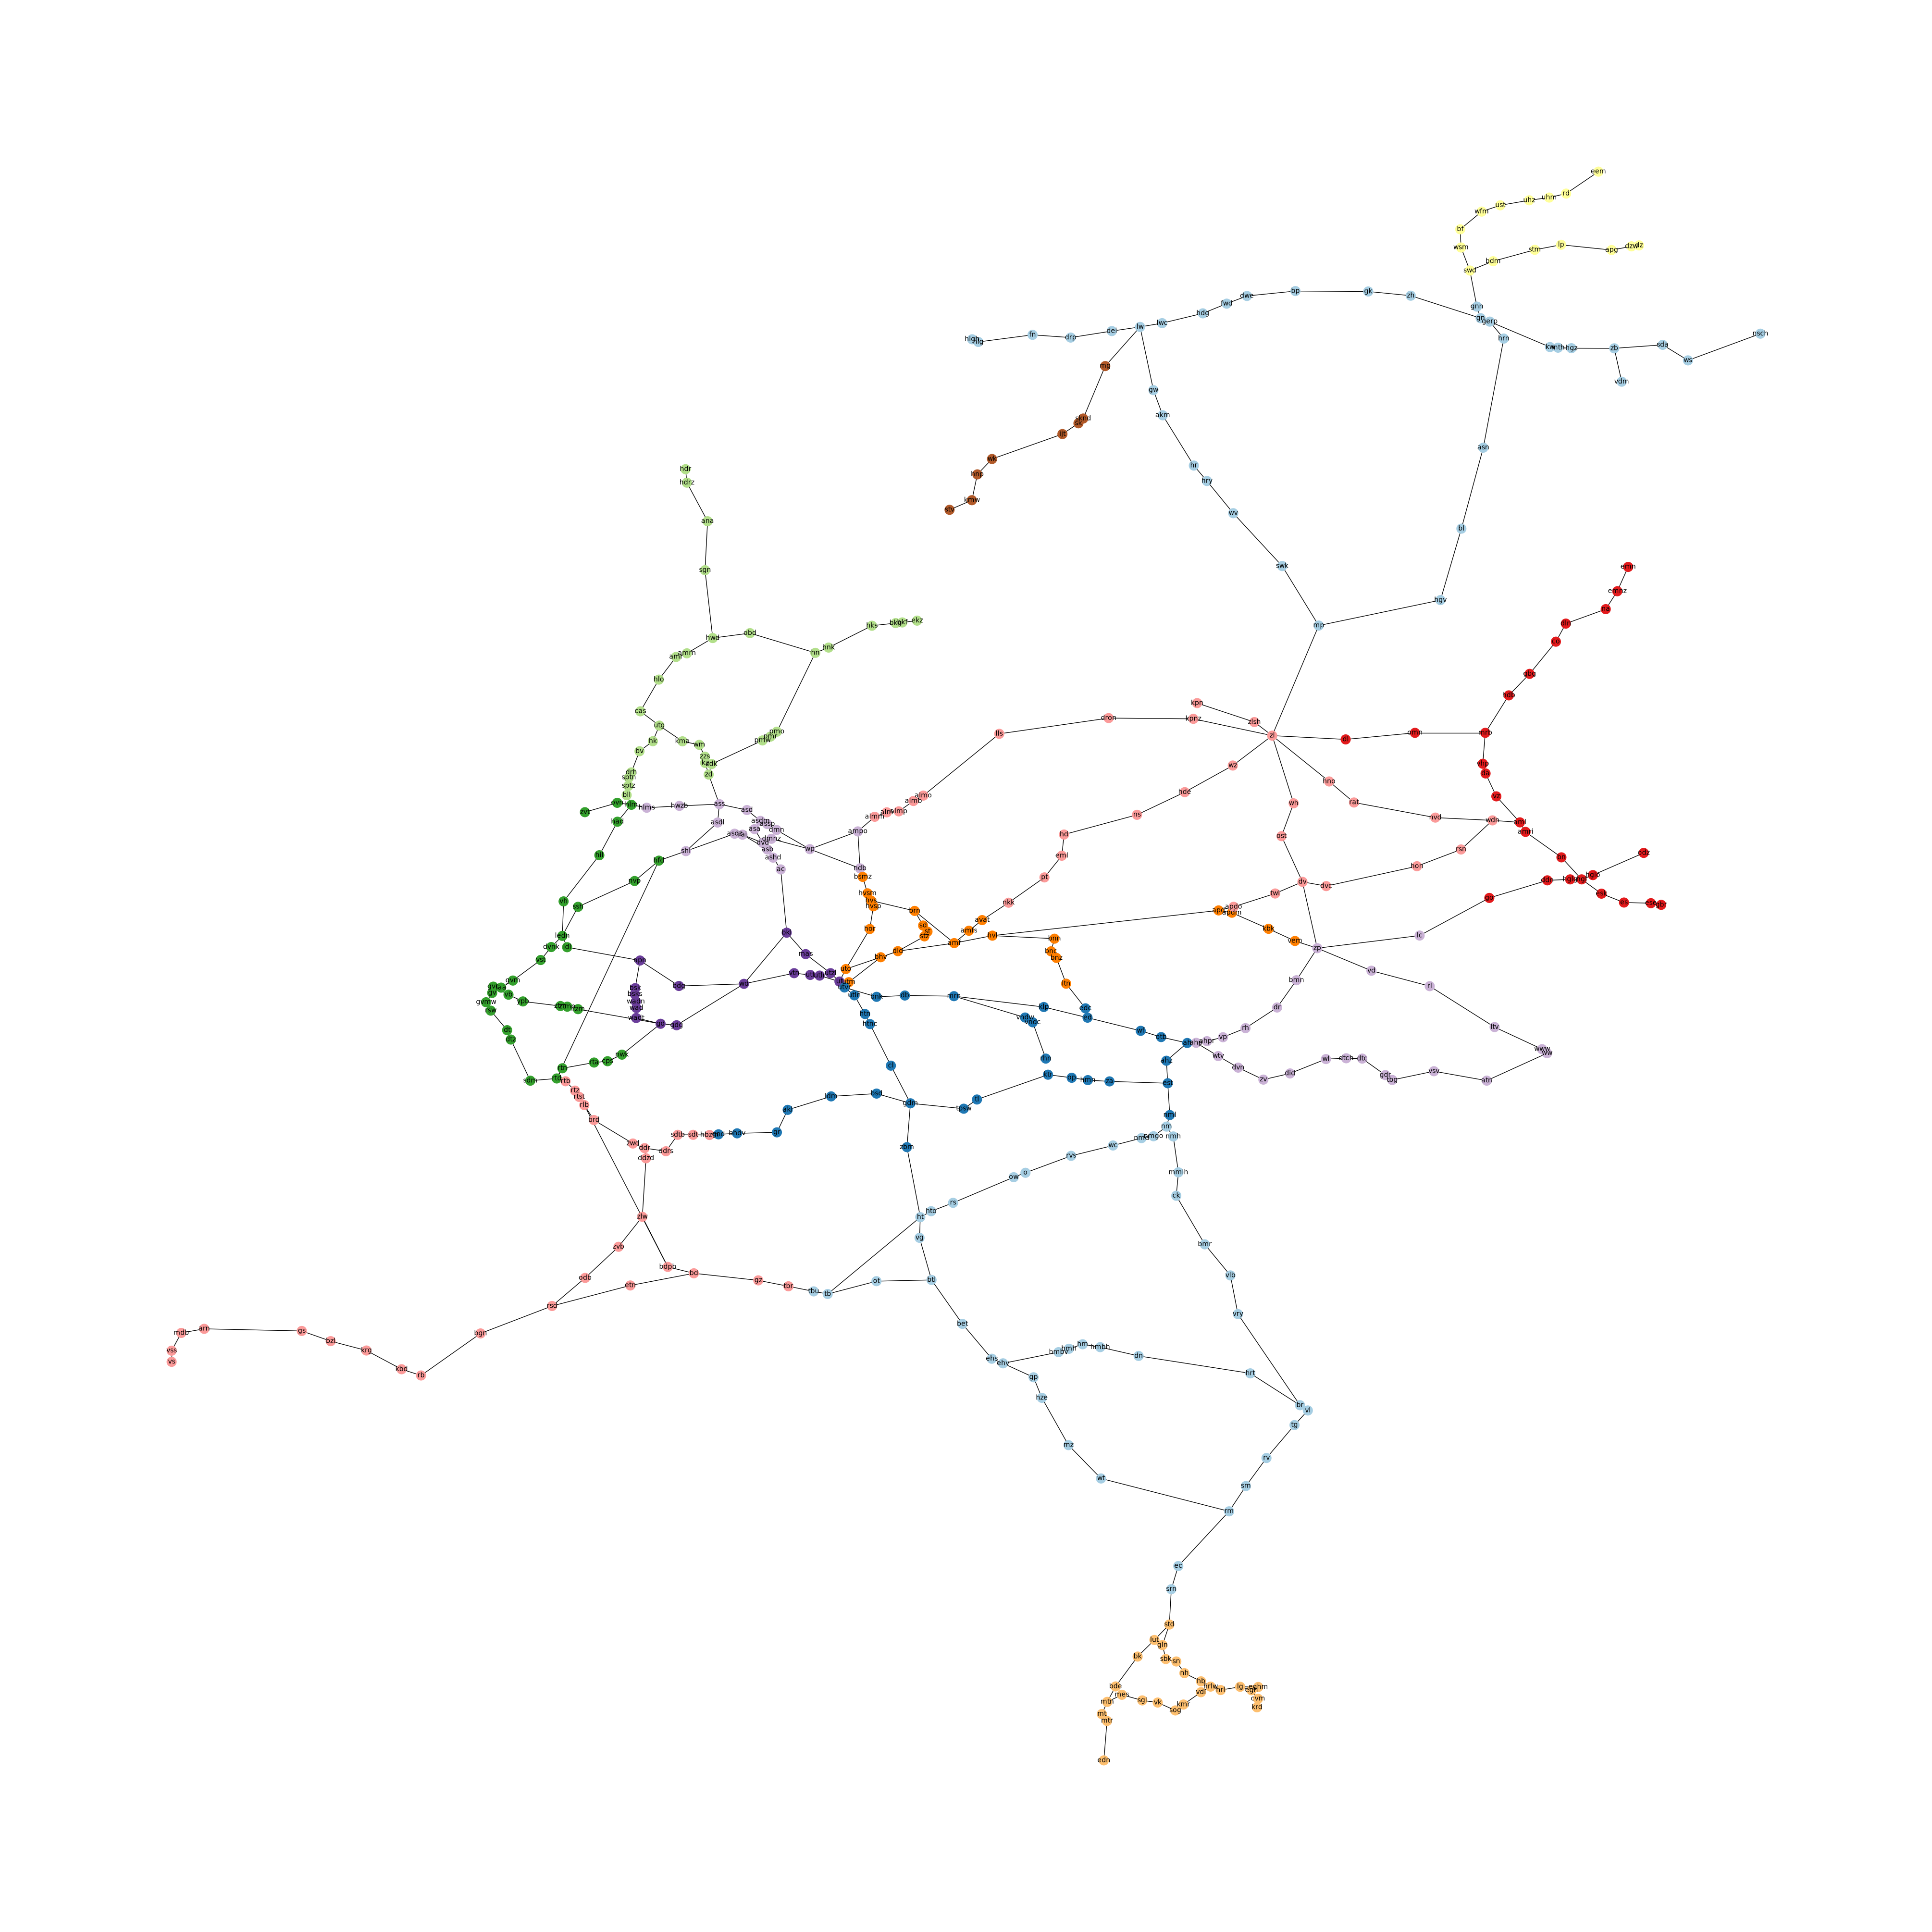

In [96]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt

# Draw each node using its geolocation
node_positions = {str(row['code']).lower(): (row['geo_lng'], row['geo_lat']) for _, row in df_stations.iterrows()}

communities = community.greedy_modularity_communities(G)

# Create a color map with a unique color for each community
color_map = plt.get_cmap('Paired')
communities_colors = {node: color_map(i / len(communities)) for i, comm in enumerate(communities) for node in comm}
node_colors = [communities_colors.get(node, 'blue') for node in G.nodes()]

nx.draw(G, pos=node_positions, with_labels=True, font_size=10, node_size=200, node_color=node_colors)

# Change canvas size
fig = plt.figure(1, figsize=(200, 80), dpi=60)
fig.set_size_inches(40, 40)
plt.show()

In [97]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

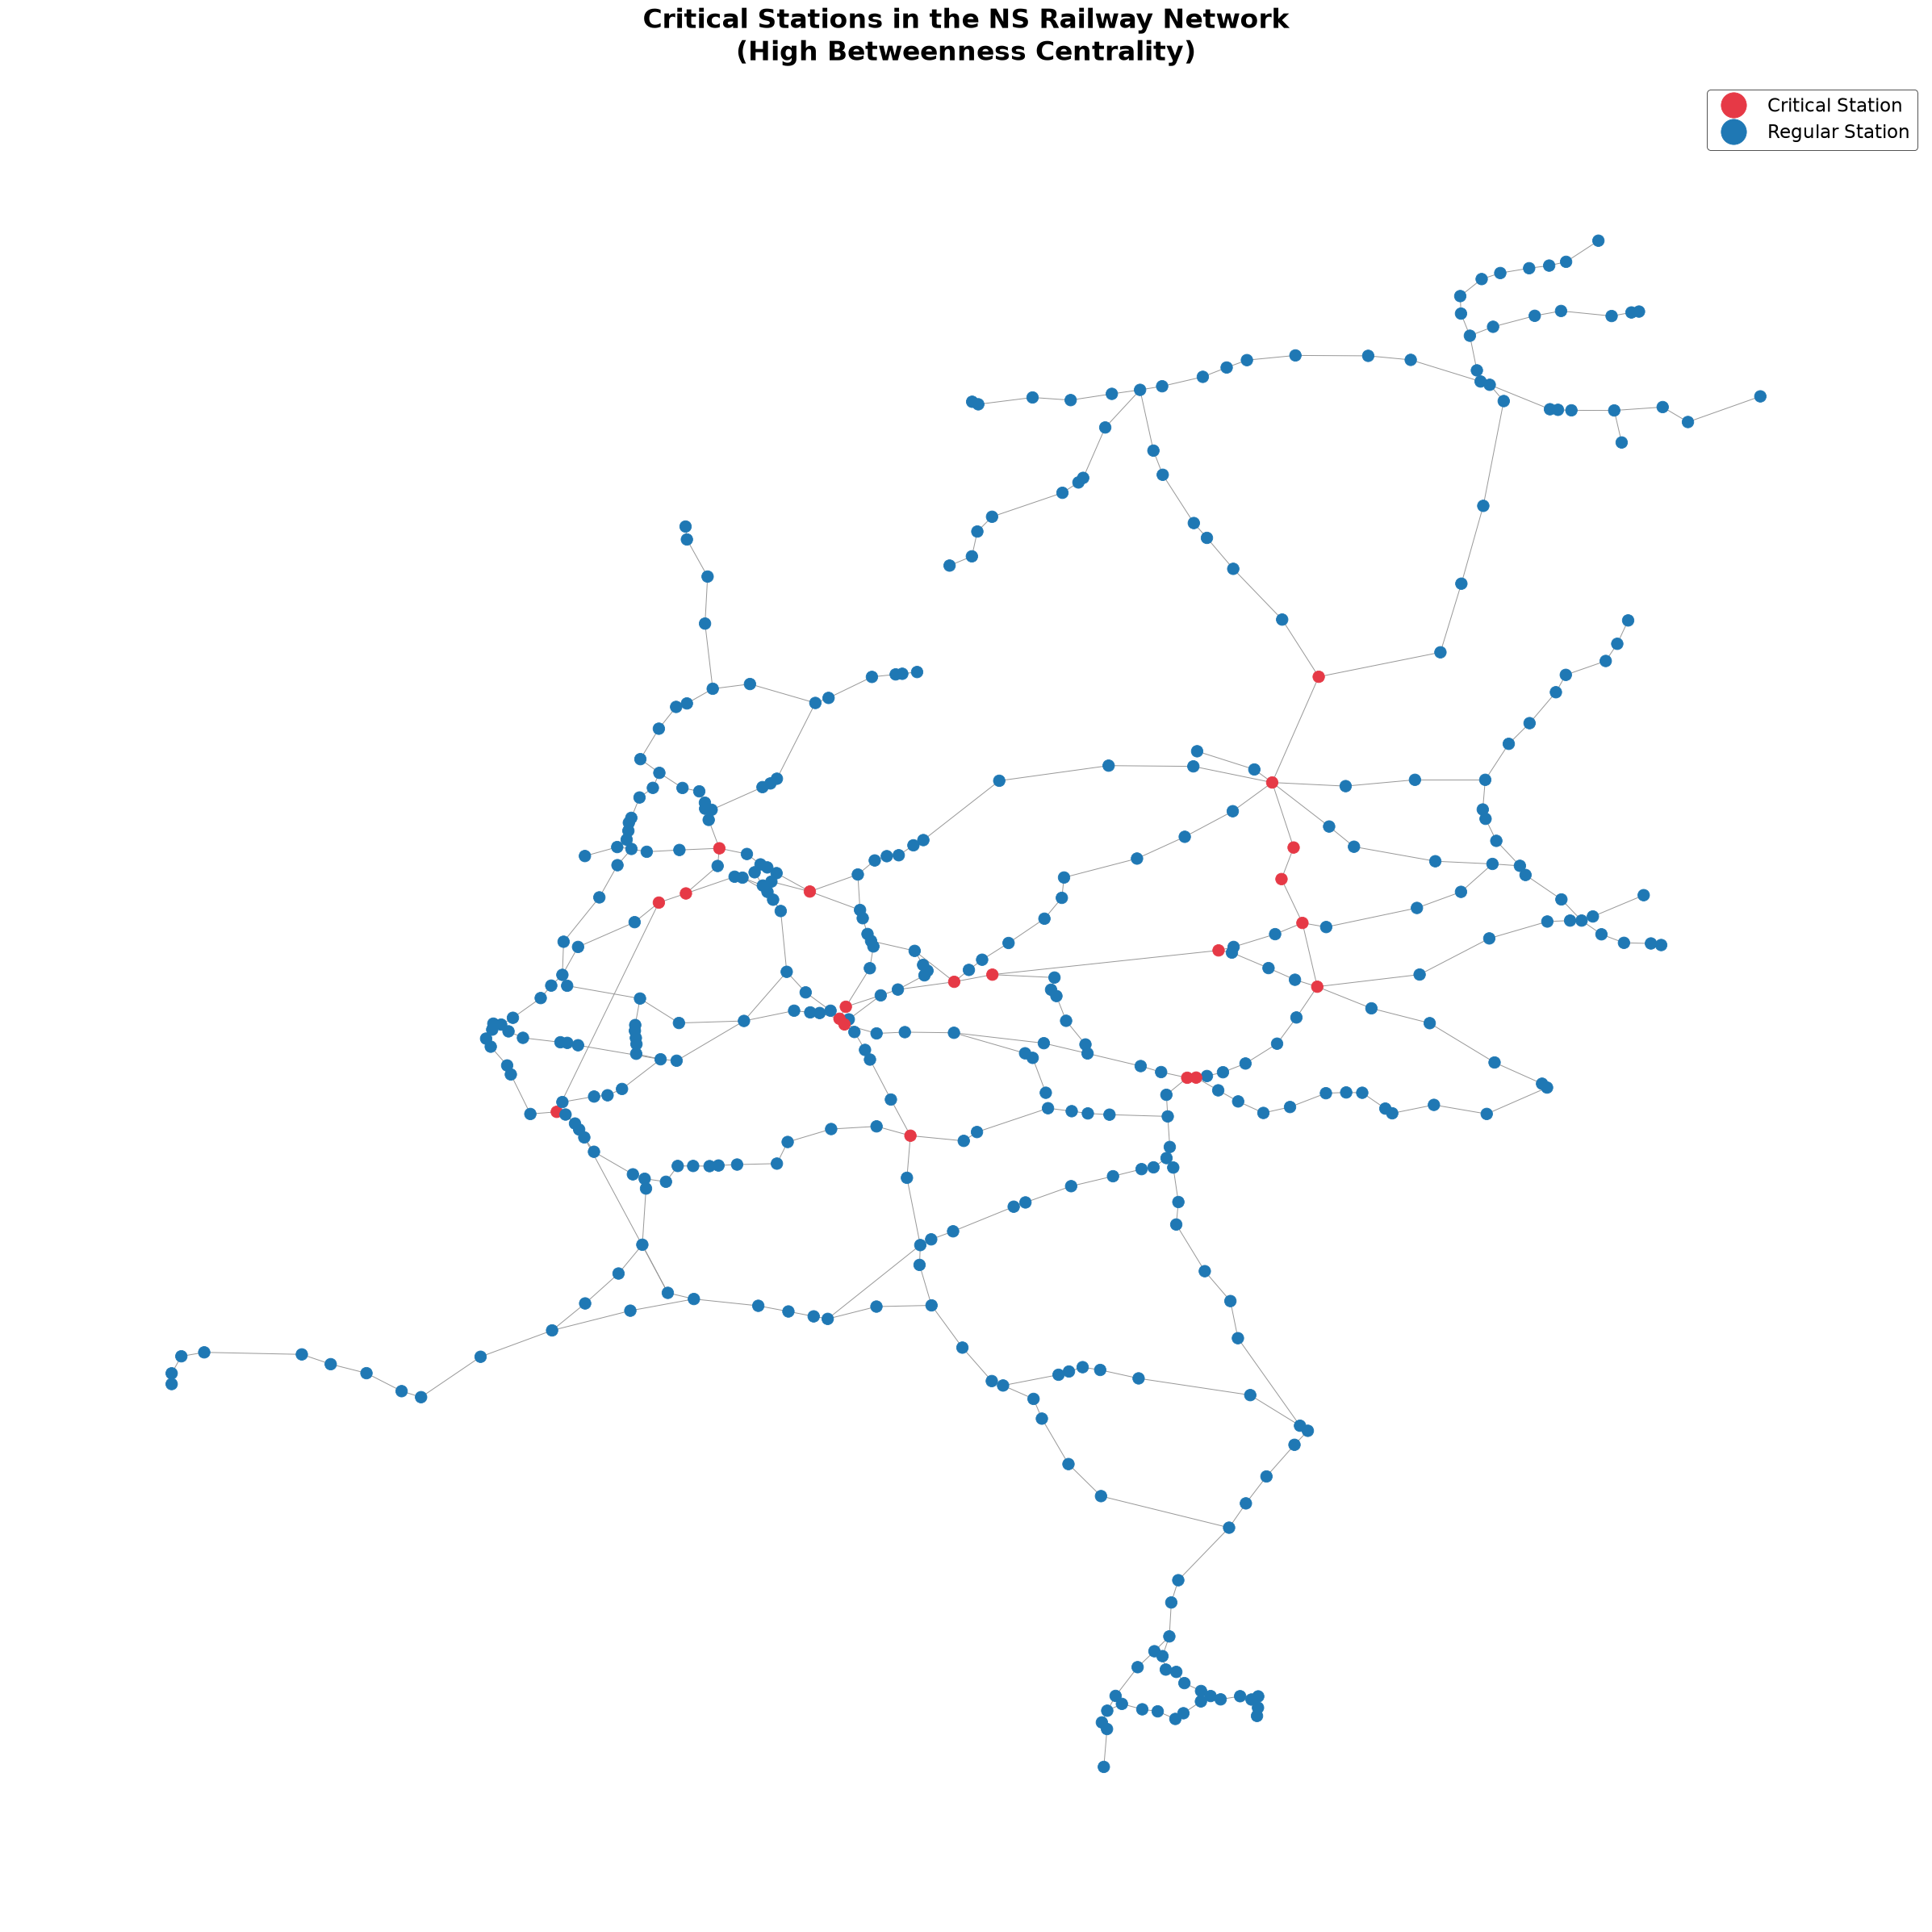

In [98]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Node positions from geolocation
node_positions = {str(row['code']).lower(): (row['geo_lng'], row['geo_lat']) for _, row in df_stations.iterrows()}

# Assign colors to nodes
node_colors = ['#e63946' if node in critical_stations else '#1f78b4' for node in G.nodes()]

# Create figure BEFORE drawing
fig, ax = plt.subplots(figsize=(40, 40), dpi=60)

nx.draw(
    G, pos=node_positions, with_labels=False,
    node_size=300, node_color=node_colors,
    edge_color='#999999', width=1.2,
    ax=ax
)

# Legend with larger marker + text
critical_marker = mlines.Line2D(
    [], [], color='#e63946', marker='o', linestyle='None',
    markersize=25, label='Critical Station'
)
normal_marker = mlines.Line2D(
    [], [], color='#1f78b4', marker='o', linestyle='None',
    markersize=25, label='Regular Station'
)

ax.legend(
    handles=[critical_marker, normal_marker],
    loc='upper right',
    fontsize=28,
    markerscale=1.5,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    borderpad=0.4,
    labelspacing=0.4
)

# Title
ax.set_title(
    "Critical Stations in the NS Railway Network\n(High Betweenness Centrality)",
    fontsize=40, fontweight='bold', pad=30
)

plt.tight_layout()
plt.show()

### 2.2 Analyse critical and weak stations/connections

How do we propose a new connection?
1. Measure original reliablility metrics (such as distance matrix)
2. Identify potential weak points (stations with high betweenness)
3. For each weak point, simulate that this specific station is out of order. Evaluate the impact by comparing metrics of affected nework to original

*   Check how much that influenced average travel distance for the whole network. Is the influence noticeable? (at least 105%)  
*   Are there any paths that suffered significantly? (1.5 times or more)

4. Add redundunt connections between chains of degree 2 if:

* Distance by train is much bigger than the real (geographical) distance, while the real distance is not too large for new connection to be feasible (e.g. train distance is 10 times bigger, and  real distance < 300 km)

5. Add a new connection

If any of condtions in Steps 3-4 are satisfied, then this station should be given a closer look and we might want to add an alternative path there.

6. Re-evaluate and compare "before-after"

Simulate disruptions (repeat Step 3) after adding a new connection. Compare the difference between original and modified network.

*   Assess how much this improved average travel distance for the whole network. Is the improvement noticeable?
*   If there was a critical problem with that station, has it been resolved?

If any of these conditions improved significantly, further consideration for adding a new station is possible. By then, we should be able suggest our stakeholders possible locations for new connections. Next steps will require a deeper research that takes into account other factors such as financial costs and landscape etc.

In [99]:
# nodes for which potential new connections need to be found
weak_high_betweenness_nodes = set()

# store preselected potential connections here
potential_connections = set()

In [100]:
# # Function to measure network connectivity after node removal
# def measure_connectivity(graph):
#     num_nodes = graph.number_of_nodes()
#     largest_component_size = len(max(nx.connected_components(graph), key=len))
#     return largest_component_size / num_nodes

# # Perform robustness analysis by iteratively removing nodes
# original_connectivity = measure_connectivity(G)
# print("Original network connectivity:", original_connectivity)

# num_nodes_to_remove = int(0.1 * G.number_of_nodes()) # Remove 10% of the nodes
# removed_nodes = rnd.sample(list(G.nodes()), num_nodes_to_remove)
# railway_graph_copy = G.copy()
# railway_graph_copy.remove_nodes_from(removed_nodes)

# new_connectivity = measure_connectivity(railway_graph_copy)
# print("Network connectivity after removing nodes:", new_connectivity)

In [101]:
# Step 1: Compute betweenness centrality
betweenness = nx.betweenness_centrality(G, weight='distance')

# Top 10 nodes by (distance-weighted) betweenness centrality
high_betweenness_nodes = [node for node, _ in
                           sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]]


# Step 2: Evaluate Impact on Average Distance
def compute_average_distance(G):
    length = dict(nx.all_pairs_dijkstra_path_length(G, weight='distance'))
    distances = [d for sub in length.values() for d in sub.values()]
    return np.mean(distances)

def evaluate_impact_on_avg_distance(graph):
    original_avg_distance = compute_average_distance(graph)

    for node in critical_stations:
        if node in graph:
            G_temp = graph.copy()
            G_temp.remove_node(node)
            new_avg_distance = compute_average_distance(G_temp)
            distance_change = new_avg_distance / original_avg_distance
            absolute_distance_change = new_avg_distance - original_avg_distance

            if distance_change > 1.05:
                weak_high_betweenness_nodes.add(node)
                node_name = get_station_name_by_code(node)  # separate variable
                print(f'Removal of node {node_name} increases average distance by more than 5%, '
                      f'specifically by {(distance_change-1)*100:.2f}% or {absolute_distance_change}')

evaluate_impact_on_avg_distance(G)

Removal of node Utrecht C. increases average distance by more than 5%, specifically by 5.42% or 79.06105712779299
Removal of node Arnhem C. increases average distance by more than 5%, specifically by 7.28% or 106.33483021217216
Removal of node Zutphen increases average distance by more than 5%, specifically by 5.23% or 76.41298550244869
Removal of node Velperpoort increases average distance by more than 5%, specifically by 6.88% or 100.50343545653482


In [102]:
# Precalculate distance matrix of original network
original_paths = dict(nx.all_pairs_dijkstra_path_length(G, weight='distance'))

In [103]:
def travel_distance_drop(G, node, max_distance_threshold=500):
    G_temp = G.copy()
    G_temp.remove_node(node)

    biggest_detour = {"source": None, "target": None, "node_removed": node, "factor": 0, "distance": 0}

    for source in G.nodes:
        if source == node:
            continue
        for target in G.nodes:
            if source != target and source != node:
                original_distance = original_paths[source][target]
                if original_distance > 0:
                    try:
                        new_distance = nx.dijkstra_path_length(G_temp, source, target, weight='distance')
                        if new_distance - original_distance > biggest_detour['distance'] and \
                            nx.dijkstra_path_length(G, source, node, weight='distance') > max_distance_threshold and \
                            nx.dijkstra_path_length(G, target, node, weight='distance') > max_distance_threshold:

                            biggest_detour['source'] = source
                            biggest_detour['target'] = target
                            biggest_detour['distance'] = new_distance - original_distance
                            biggest_detour['factor'] = new_distance / original_distance
                    except nx.NetworkXNoPath:
                        continue

    if biggest_detour['distance'] > 0:
        weak_high_betweenness_nodes.add(node)
        node_removed = get_station_name_by_code(biggest_detour['node_removed'])
        source = get_station_name_by_code(biggest_detour['source'])
        target = get_station_name_by_code(biggest_detour['target'])
        factor = biggest_detour['factor']
        print(f"Removal of node {node_removed} increases the distance between {source} and {target} by a measure of {factor:.2f} times")
    else:
        print(f"Removal of {get_station_name_by_code(node)} caused no qualifying detour.")


# Iterate over the top 10 high-betweenness nodes (the precomputed candidate list),
# not weak_high_betweenness_nodes, which this function fills in as a side effect
for node in high_betweenness_nodes[:10]:
    if node in G:
        travel_distance_drop(G, node)

# Update critical_stations as a set to allow .update(); convert back to list/set consistently elsewhere
critical_stations = set(critical_stations)
critical_stations.update(weak_high_betweenness_nodes)

Removal of node Zwolle increases the distance between Emmen and Oostvaarders by a measure of 1.44 times
Removal of node Utrecht C. increases the distance between Eindhoven C. and Oostvaarders by a measure of 1.48 times
Removal of Meppel caused no qualifying detour.
Removal of node Amersfoort C. increases the distance between Goverwelle and Wezep by a measure of 1.39 times
Removal of node Vaartsche Rijn increases the distance between Eindhoven C. and Buiten by a measure of 1.48 times
Removal of node Arnhem C. increases the distance between Aalten and Venray by a measure of 2.34 times
Removal of node Geldermalsen increases the distance between Eindhoven C. and Abcoude by a measure of 1.61 times
Removal of node Velperpoort increases the distance between Aalten and Vierlingsbeek by a measure of 2.01 times
Removal of node Overvecht increases the distance between Blauwe Zoom and 't Harde by a measure of 1.37 times
Removal of node Zutphen increases the distance between Enschede and Aalten by 

In [104]:
print(weak_high_betweenness_nodes)

{'zl', 'ahp', 'utvr', 'amf', 'ah', 'ut', 'gdm', 'uto', 'zp'}


C:\Users\Andrii\AppData\Local\Temp\ipykernel_34572\1894779063.py:10: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  fig = plt.figure(1, figsize=(200, 80), dpi=60)


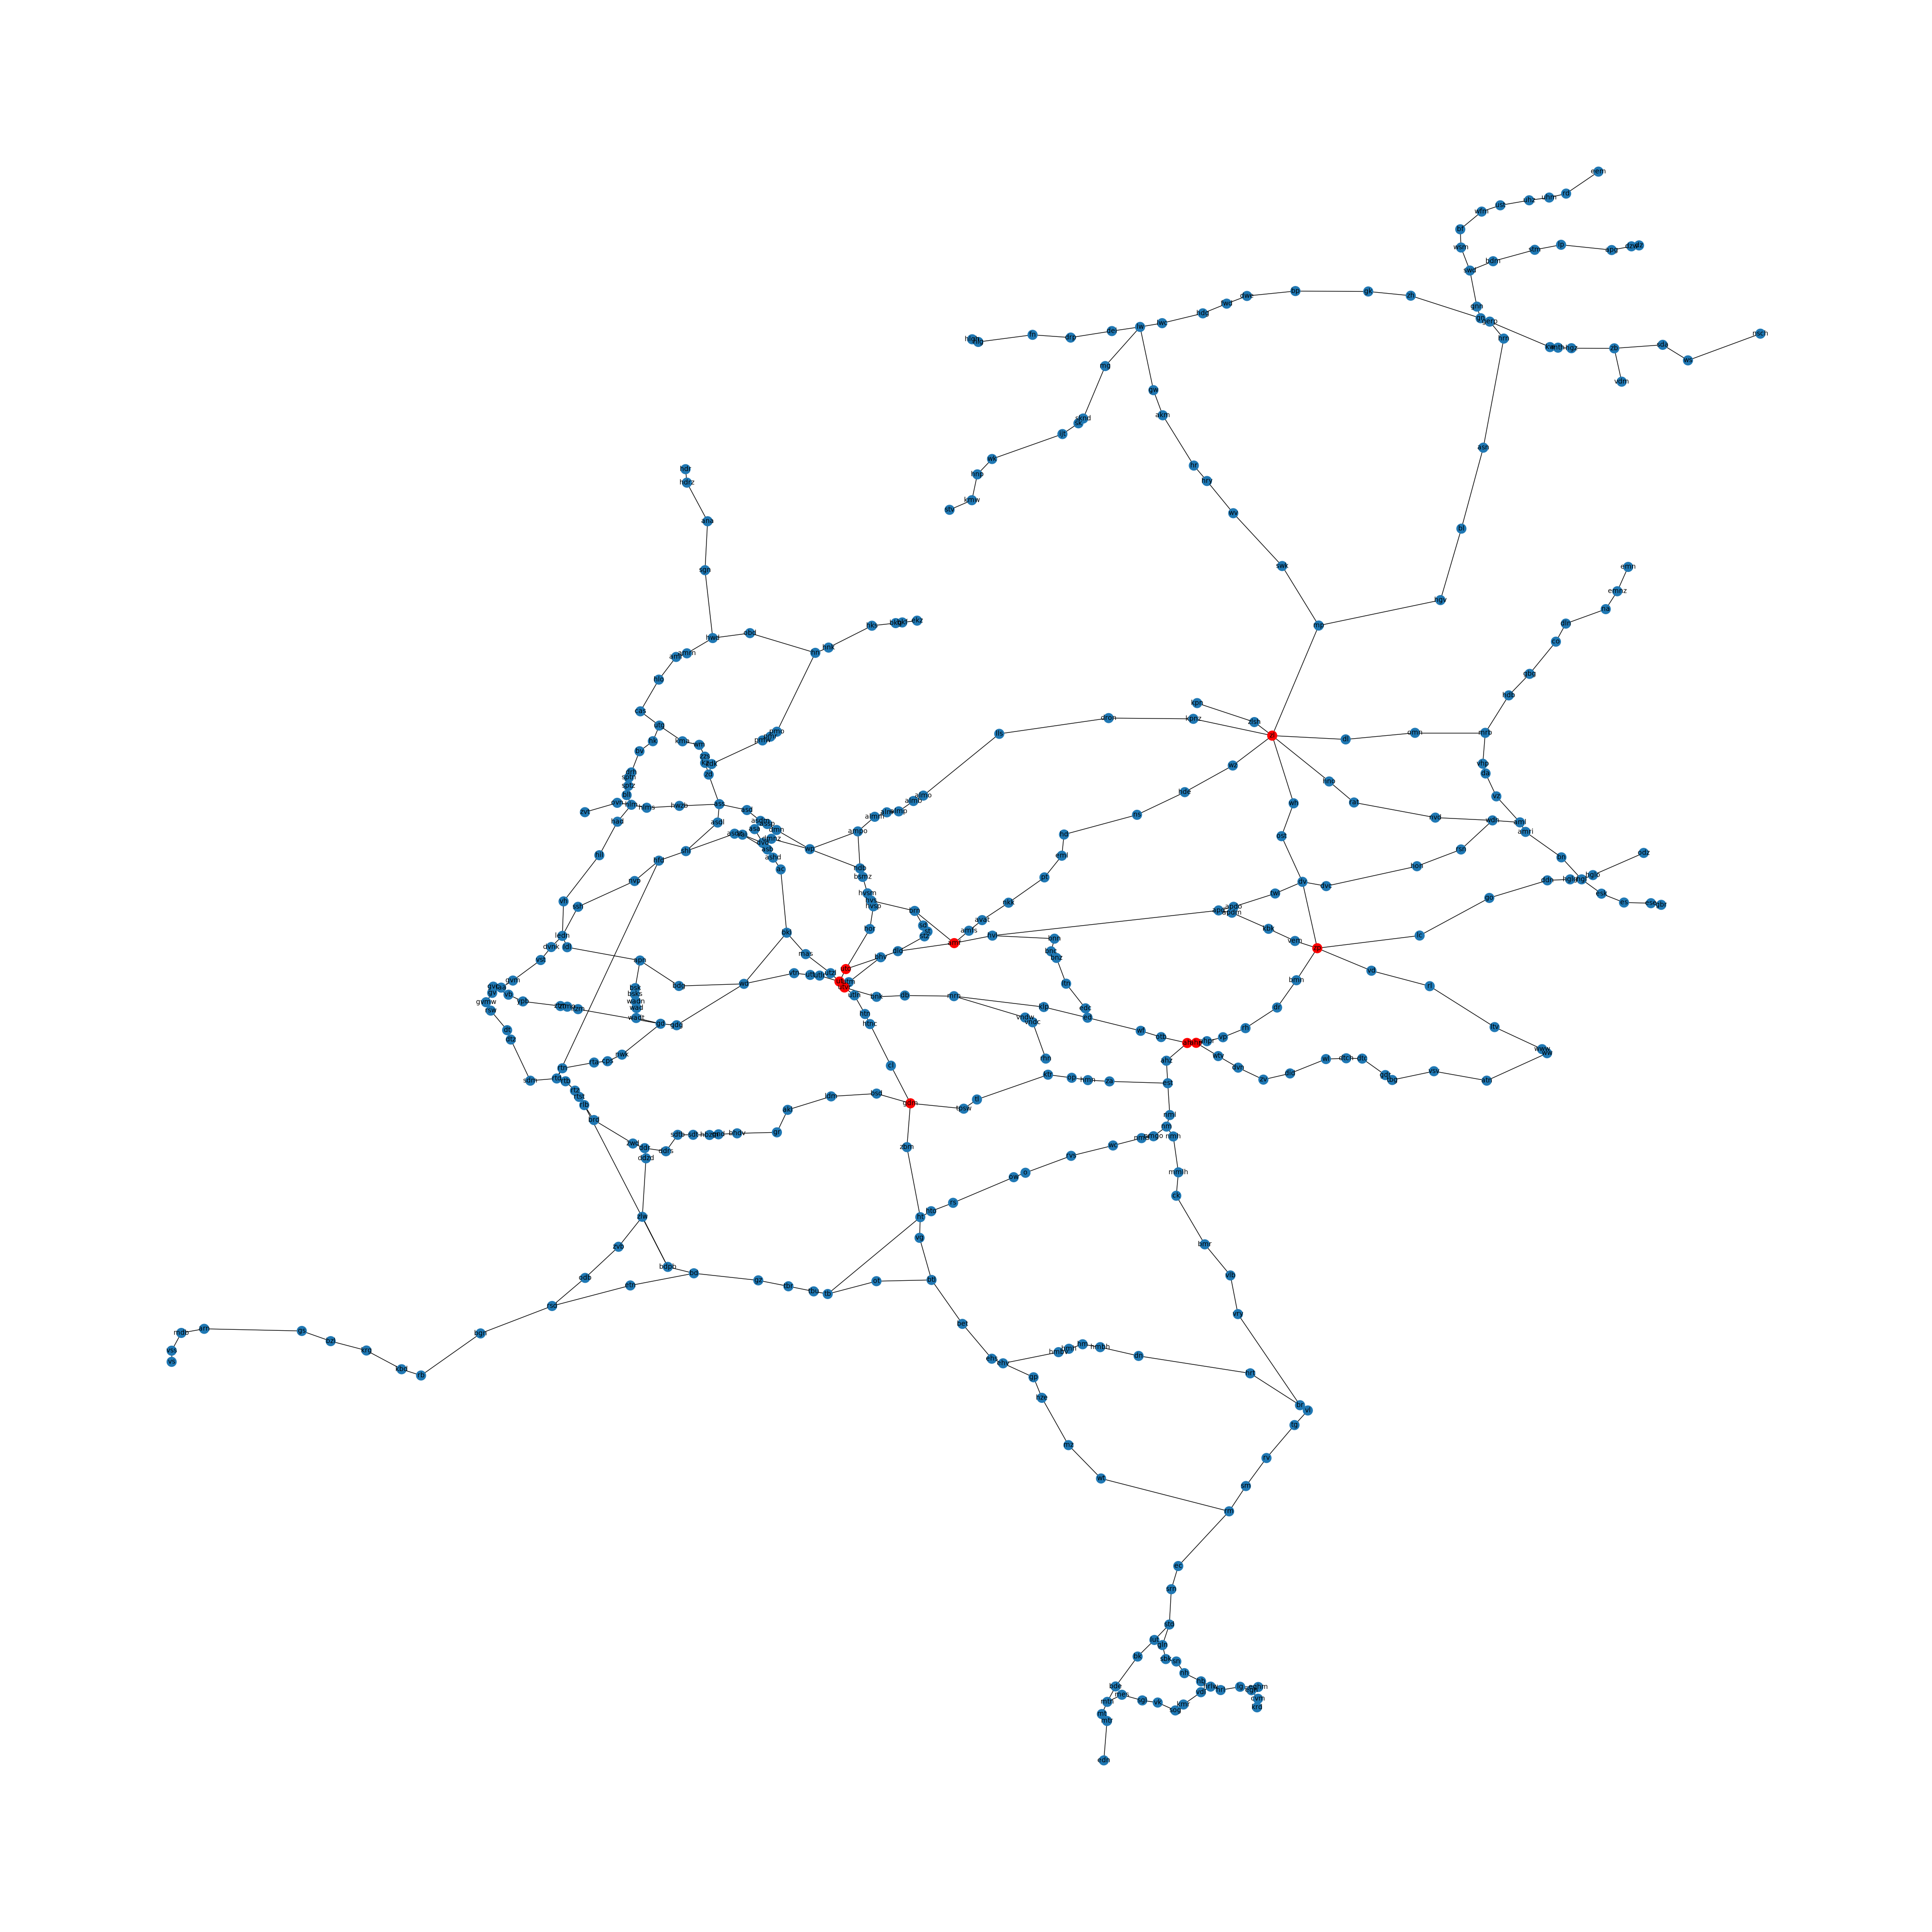

In [105]:
# Draw each node using its geolocation
node_positions = {str(row['code']).lower(): (row['geo_lng'], row['geo_lat']) for _, row in df_stations.iterrows()}

# Assign colors to nodes
node_colors = ['red' if node in weak_high_betweenness_nodes else '#1f78b4' for node in G.nodes()]  # Critical nodes are red, default color is blue

nx.draw(G, pos=node_positions, with_labels=True, font_size=10, node_size=200, node_color=node_colors)

# Change canvas size
fig = plt.figure(1, figsize=(200, 80), dpi=60)
fig.set_size_inches(40, 40)
plt.show()

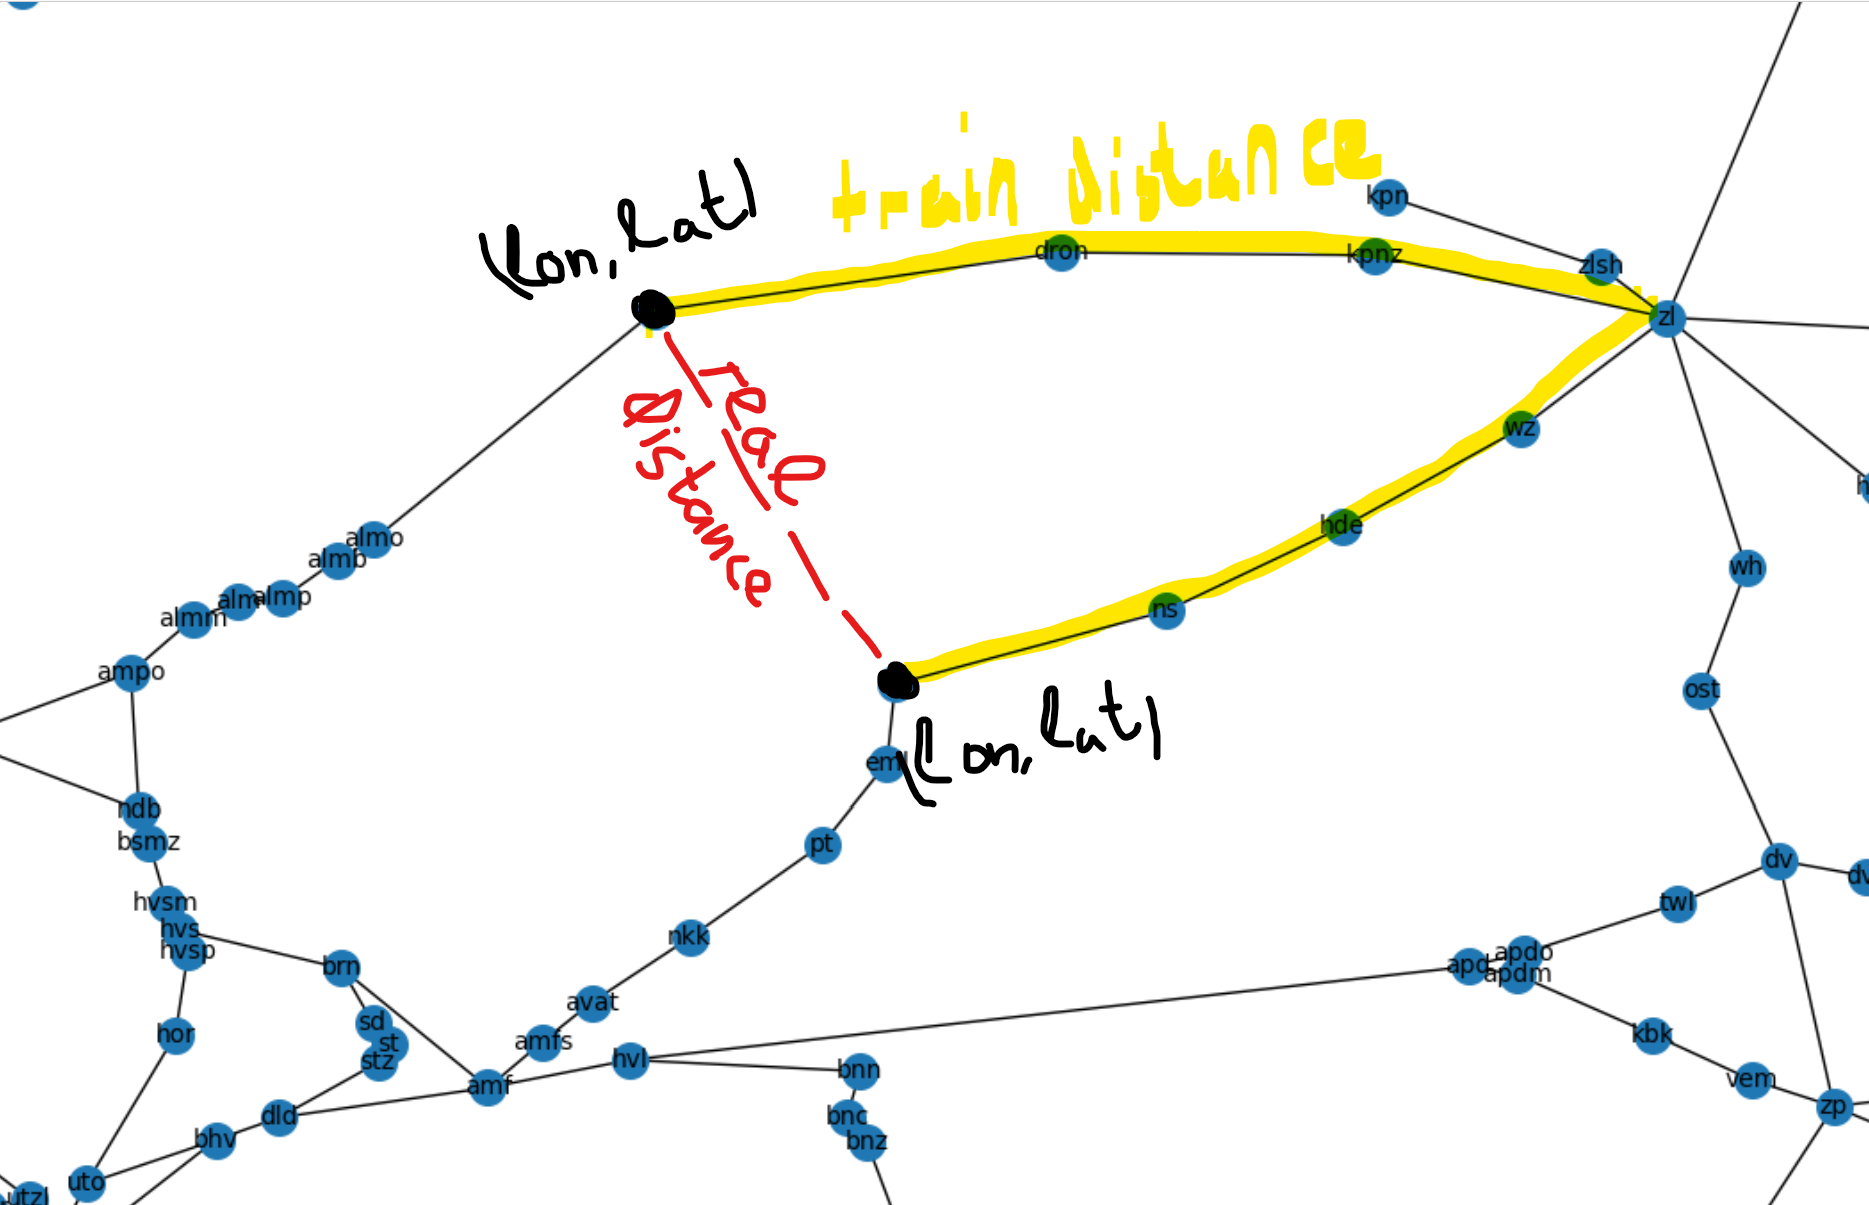

Sometimes it also makes sense to add a connection between two stations that are physically close but the train travel distance between them is relatively high. This way, we create a short alternative path in case something goes wrong with original path, for example, a train is stuck on the railway and effectively blocks movement through this part of the network.       
Looking at picture above, we can see a huge region bounded by edges, which is problematic in case of disruptions. We can see that two stations (marked with black color) have travel distance by train much bigger than the actual (euclidian) distance, so creating a new connection between them can increase robustness of the network

In [106]:
def calculate_distance_by_geolocation(source, target):
    real_distance = geopy.distance.geodesic(get_station_location_by_code(source), get_station_location_by_code(target)).km * 10  # Convert km to 0.1 km units
    return real_distance

In [ ]:
# Identify pairs of stations where the train route is much longer than the direct geodesic distance.

distance_factor_threshold = 4  # The factor by which the train distance must exceed the real distance to be considered.
absolute_difference_threshold = 300_0  # The maximum allowed absolute difference in distances (in 0.1 km) to be considered.

for i, source in enumerate(G.nodes):
  for target in list(G.nodes)[i+1:]:  # Ensure each pair is considered only once
    real_distance = calculate_distance_by_geolocation(source, target)
    train_distance = original_paths[source][target]
    distance_factor = train_distance / real_distance
    absolute_difference = abs(train_distance - real_distance)

    if distance_factor > distance_factor_threshold and absolute_difference < absolute_difference_threshold:
      potential_connections.add((source, target))  # Add potential connection to list
      print(get_station_name_by_code(source) + " to " + get_station_name_by_code(target))

Maliebaan to Overvecht
Maliebaan to Utrecht C.
Maliebaan to Zuilen
Maliebaan to Vaartsche Rijn
Maliebaan to Bunnik
Maliebaan to Leidsche Rijn
Maliebaan to Lunetten
Den Helder to Stavoren
Den Helder to Koudum-Molkwerum
Den Helder to Hindeloopen
Den Helder to Workum
Den Helder to IJlst
Den Helder to Sneek
Den Helder to Sneek Noord
Den Helder to Mantgum
Den Helder to Harlingen Haven
Den Helder to Harlingen
Den Helder to Franeker
Den Helder to Dronryp
Den Helder to Deinum
Den Helder Zuid to Stavoren
Den Helder Zuid to Koudum-Molkwerum
Den Helder Zuid to Hindeloopen
Den Helder Zuid to Workum
Den Helder Zuid to IJlst
Den Helder Zuid to Sneek
Den Helder Zuid to Sneek Noord
Den Helder Zuid to Mantgum
Den Helder Zuid to Harlingen Haven
Den Helder Zuid to Harlingen
Den Helder Zuid to Franeker
Den Helder Zuid to Dronryp
Anna Paulowna to Stavoren
Anna Paulowna to Koudum-Molkwerum
Anna Paulowna to Hindeloopen
Anna Paulowna to Workum
Anna Paulowna to IJlst
Anna Paulowna to Sneek
Anna Paulowna to Sne

In [ ]:
print(len(potential_connections))

### 2.3 Propose new connections

Add a new connection and evaluate the improvement
* Did the betweenness of critical high betweenness nodes reduce after adding a new connection?
* Did the average travel distance after removal of high betweenness node improve compared to original network?
* If there were routes dramatically affected by removcal of high betweenness node, did the situation improve?

In [ ]:
def add_new_edge(graph, source, target):
  """
  Add a new edge between two stations with a weight equal to their Euclidean distance.
  """
  distance = calculate_distance_by_geolocation(source, target)
  graph.add_edge(source, target, weight=distance)

Plot the connection between nodes that are geografically close but the train travel distance between them is N times bigger than geografic distance

NetworkXError: Node 'dtz' has no position.

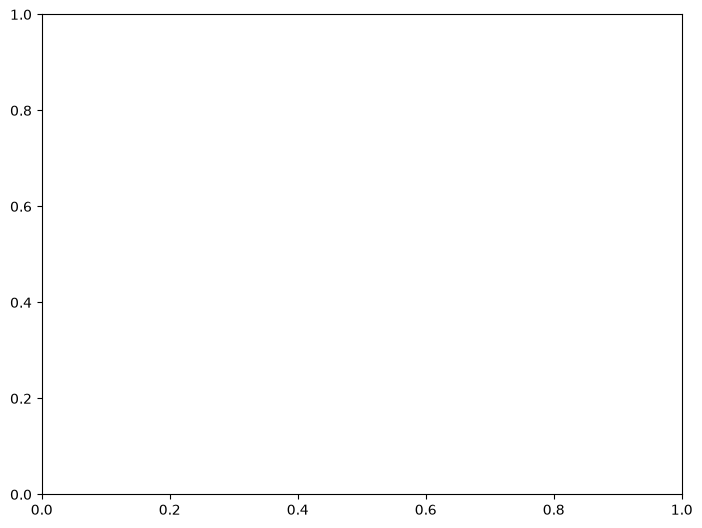

In [ ]:
G_copy = G.copy()

for source, target in potential_connections:
    add_new_edge(G_copy, source, target)


# Draw each node using its geolocation
node_positions = {str(row['code']).lower(): (row['geo_lng'], row['geo_lat']) for _, row in df_stations.iterrows()}

# Assign colors to edges
edge_colors = ['orange' if (edge[0], edge[1]) in potential_connections or (edge[1], edge[0]) in potential_connections else 'black' for edge in G_copy.edges()]

nx.draw(G_copy, pos=node_positions, with_labels=True, font_size=10, node_size=200, edge_color=edge_colors)

# Change canvas size
fig = plt.figure(1, figsize=(200, 80), dpi=60)
fig.set_size_inches(40, 40)
plt.show()


To propose new connections, we performed mutilple steps to identify weak nodes (we need to add alternative paths that do not go through them) and nodes that are geografically close but far by train. This way, we located (preselected) potential problematic areas, and did our best to manually select edges that solve the problems.

In [ ]:
G_modified = G.copy()

manually_selected_connections = set((("est", "zv"), ("zv", "rh"), ("lls", "hr"), ("ah", "apd"), ("apd", "hd"), ("hd", "lls"), ("gd", "ddr"), ("amf", "mrn"), ("rhn", "ktr"), ("hgv", "emn")))

print(len(manually_selected_connections))

for source, target in manually_selected_connections:
    add_new_edge(G_modified, source, target)


# Draw each node using its geolocation
node_positions = {str(row['code']).lower(): (row['geo_lng'], row['geo_lat']) for _, row in df_stations.iterrows()}

# Show critical nodes
node_colors = ['red' if node in critical_stations else '#1f78b4' for node in G.nodes()]  # Critical nodes are red, default color is blue

# Assign colors to edges
edge_colors = ['orange' if (edge[0], edge[1]) in manually_selected_connections or (edge[1], edge[0]) in manually_selected_connections else 'black' for edge in G_modified.edges()]

nx.draw(G_modified, pos=node_positions, with_labels=True, font_size=10, node_size=170, edge_color=edge_colors, node_color=node_colors)

# Change canvas size
fig = plt.figure(1, figsize=(200, 80), dpi=60)
fig.set_size_inches(40, 40)
plt.show()

In [ ]:
evaluate_impact_on_avg_distance(G_modified)

### 3. Results


**Critical stations**
- ~20 stations (top 5% by betweenness) flagged as critical
- Zwolle stands out: removing it cuts off Friesland, Groningen, and (indirectly) Drenthe -- about 1.8 million people -- with no efficient alternative route
- Simulated removal of several critical stations increases average network travel distance by more than 5%

**Proposed connections**
- A set of station pairs was identified as geographically close but far apart by train -- these are the best candidates for new, short connections
- 10 connections were manually selected from that set and added to the network
- *[Fill in after re-running the final cells: did the average-distance increase from removing critical stations go down once these connections were added, and by how much?]*

**Bottom line**
A small number of targeted connections can measurably reduce the network's exposure to single-station disruptions, without a full redesign.

### 4. Discussion
- Doesn't model platform/track-level redundancy at a station
- Weighted by distance, not travel time or passenger volume
- New-connection distances are straight-line estimates, not real feasible routes